# Word Co-occurrence Graph

In this notebook, we will create a word co-occurrence graph to visualize the relationships between the most common words in the German corpus. A co-occurrence graph represents words as nodes and the connections (edges) between them indicate that they appear next to each other in the text.

Here's the plan:
1.  **Identify Top Words**: We'll start by loading our word count data and selecting the top 50 most frequent words.
2.  **Build the Graph**: We will use the `networkx` library to create an undirected graph. Each of the top 50 words will be a node.
3.  **Create Edges**: We will process the sentences from our corpus. An edge will be created between two words if they are adjacent in a sentence and both are in our top 50 list. The weight of the edge will represent how many times they appear together.
4.  **Analyze the Graph**: We will identify the "core" words by looking at the degree of each node (the number of connections it has).
5.  **Visualize**: We will plot the graph to see the structure of word connections. The size of the nodes will be proportional to their degree.

In [2]:
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import spacy

# --- Configuration ---
DATA_DIR = "../data"
WORD_COUNTS_FILE = "word_counts_with_stopwords.csv"
SENTENCES_DIR = "deu_mixed-typical_2011_100K"
SENTENCES_FILE = "deu_mixed-typical_2011_100K-sentences.txt"
TOP_N_WORDS = 50

# --- Load Data ---
word_counts_path = os.path.join(DATA_DIR, WORD_COUNTS_FILE)
sentences_path = os.path.join(DATA_DIR, SENTENCES_DIR, SENTENCES_FILE)

df_words = pd.read_csv(word_counts_path)
top_words = set(df_words.head(TOP_N_WORDS)['word'])

# --- Load spaCy model ---
# We use this to tokenize sentences properly.
nlp = spacy.load("de_core_news_sm")

# --- Build the Graph ---
G = nx.Graph()

# Add nodes
for word in top_words:
    G.add_node(word)

print(f"Processing sentences from '{SENTENCES_FILE}'...")
try:
    with open(sentences_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Building graph"):
            parts = line.split('\t', 1)
            if len(parts) == 2:
                sentence = parts[1]
                doc = nlp(sentence)
                
                # Get lemmas for the sentence
                lemmas = [token.lemma_.lower() for token in doc if token.is_alpha]
                
                # Create edges for adjacent words in the top list
                for i in range(len(lemmas) - 1):
                    word1 = lemmas[i]
                    word2 = lemmas[i+1]
                    
                    if word1 in top_words and word2 in top_words and word1 != word2:
                        if G.has_edge(word1, word2):
                            G[word1][word2]['weight'] += 1
                        else:
                            G.add_edge(word1, word2, weight=1)
except FileNotFoundError:
    print(f"Error: The file '{sentences_path}' was not found.")

print("Graph construction complete.")

Processing sentences from 'deu_mixed-typical_2011_100K-sentences.txt'...


Building graph: 100000it [05:25, 306.77it/s]

Graph construction complete.


Top 10 core words (most connections):


,word,degree
25,sie,49
11,es,49
38,sein,49
6,der,49
33,ein,49
31,nur,49
37,noch,48
34,in,48
40,und,47
35,von,47


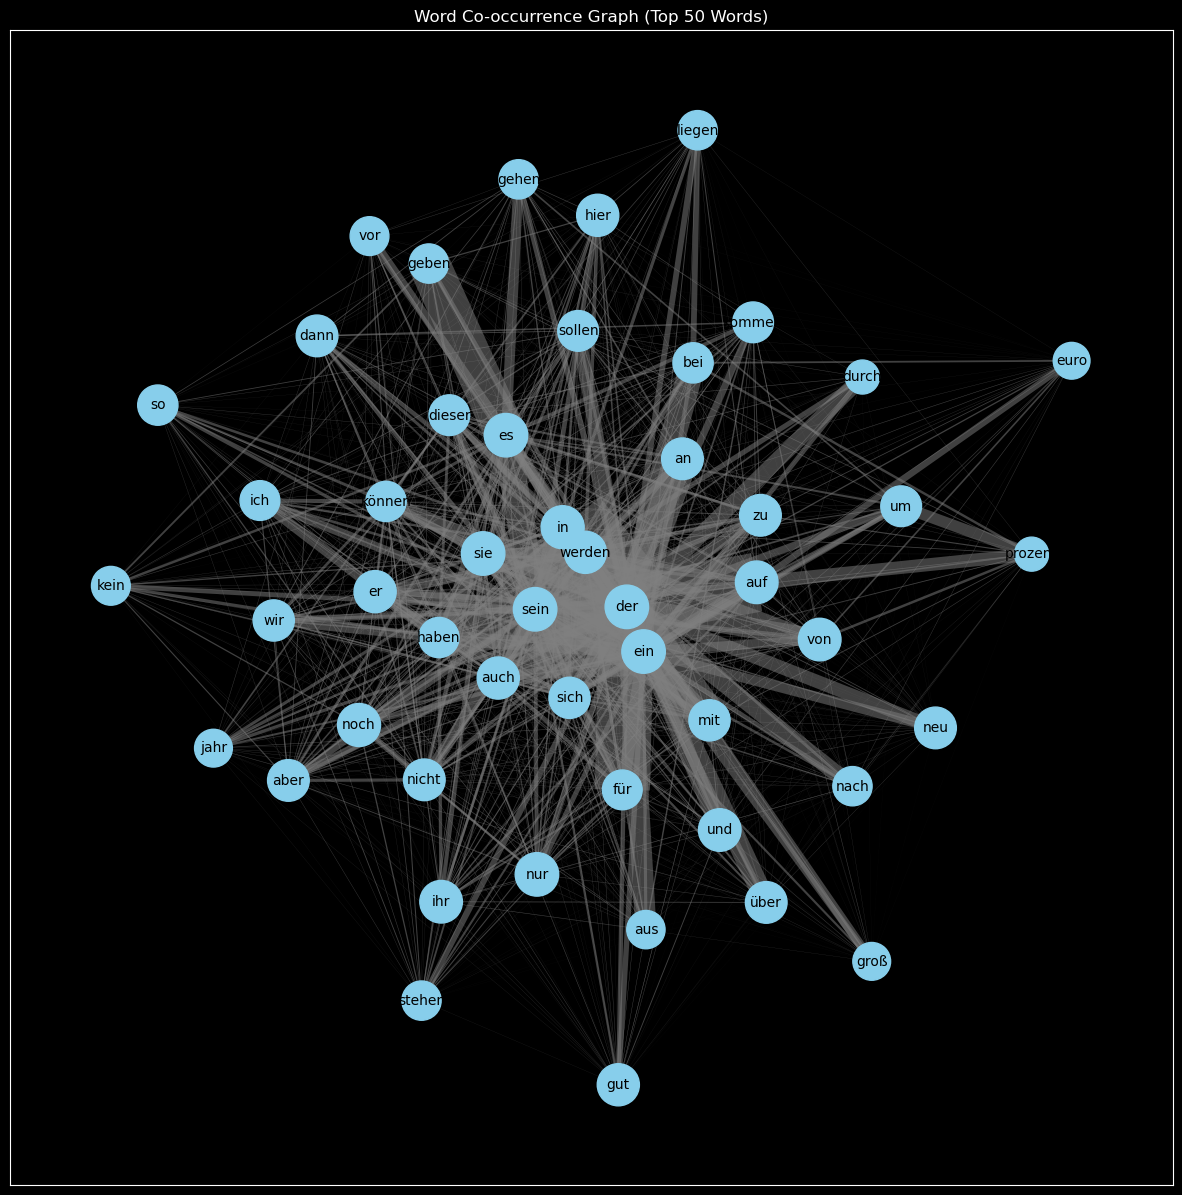

In [9]:
# --- Analyze the Graph ---
# Calculate the degree for each node
degrees = G.degree()
df_degrees = pd.DataFrame(degrees, columns=['word', 'degree']).sort_values(by='degree', ascending=False)

print("Top 10 core words (most connections):")
display(df_degrees.head(10))

# --- Visualize the Graph ---
plt.figure(figsize=(15, 15))

# Use a spring layout for better visualization
pos = nx.spring_layout(G, k=0.3, iterations=50)

# Get node sizes based on degree
node_sizes = [d * 20 for _, d in degrees]

# Get edge widths based on weight
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
# Normalize edge widths for better visualization
max_weight = max(edge_weights)
edge_widths_normalized = [100 * (w / max_weight) for w in edge_weights]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=edge_widths_normalized, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title('Word Co-occurrence Graph (Top 50 Words)')
plt.show()